<a href="https://colab.research.google.com/github/DAKSHKALIYA/Exploratory-Data-Analysis-Titanic/blob/main/Titanic_Exploratory_Data_Analysis_(EDA)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving titanic.csv to titanic.csv
Shape: (887, 8)

Columns:
 Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Siblings/Spouses Aboard',
       'Parents/Children Aboard', 'Fare'],
      dtype='object')

Data Types:
 Survived                     int64
Pclass                       int64
Name                        object
Sex                         object
Age                        float64
Siblings/Spouses Aboard      int64
Parents/Children Aboard      int64
Fare                       float64
dtype: object

Missing Values:
 Survived                   0
Pclass                     0
Name                       0
Sex                        0
Age                        0
Siblings/Spouses Aboard    0
Parents/Children Aboard    0
Fare                       0
dtype: int64

Summary:
           Survived      Pclass                Name   Sex         Age  \
count   887.000000  887.000000                 887   887  887.000000   
unique         NaN         NaN                 887     2         NaN  

/tmp/ipykernel_10340/1049632939.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


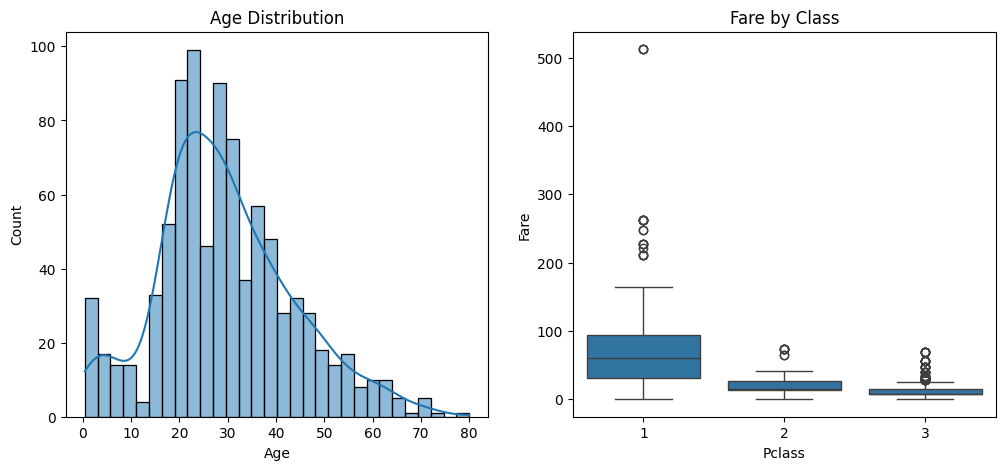

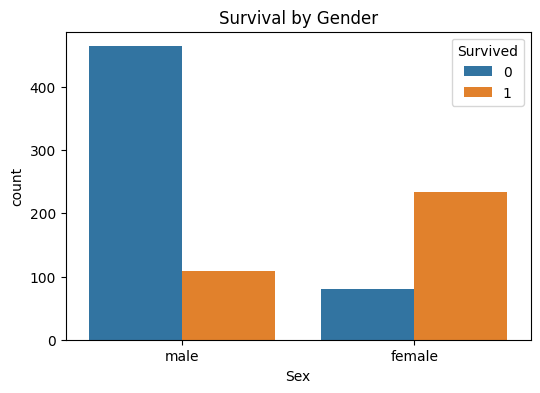

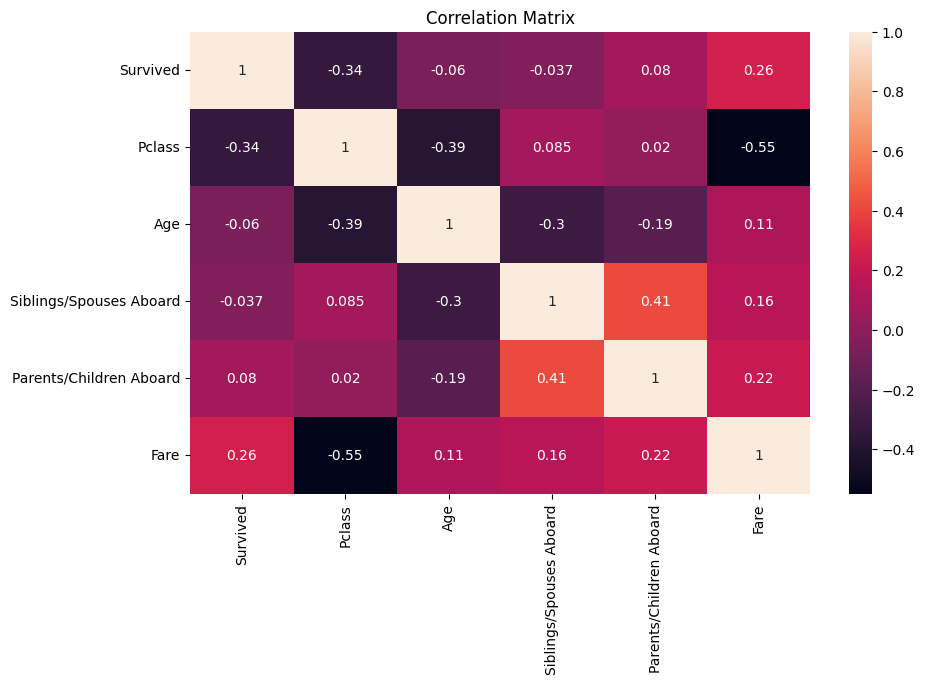


Survival % by Class:

Survived          0          1
Pclass                        
1         37.037037  62.962963
2         52.717391  47.282609
3         75.564682  24.435318


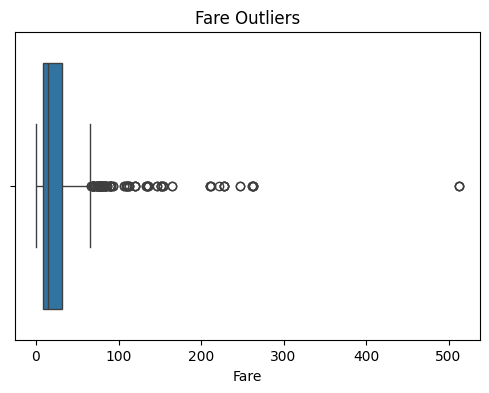

Outliers (Fare > Z-score 3): 20


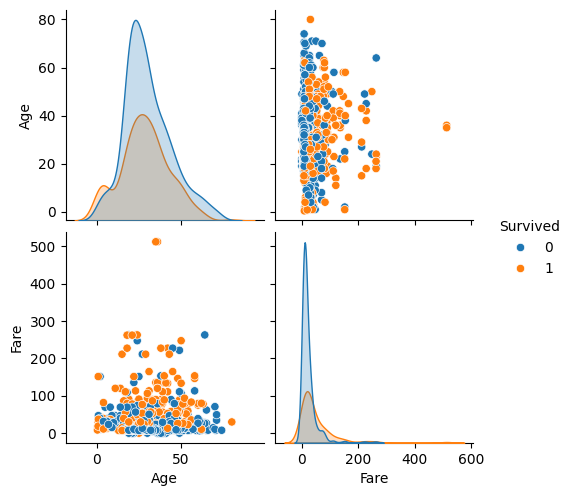

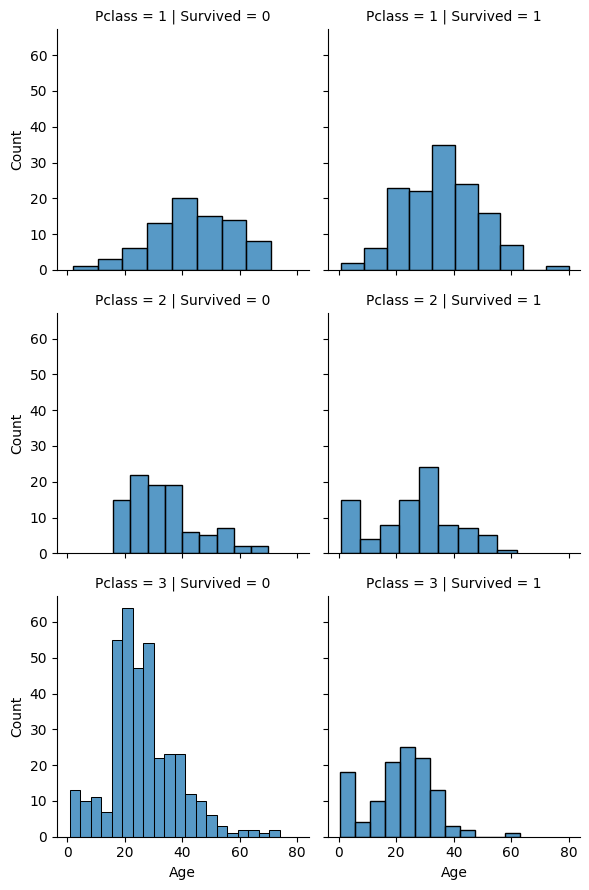

In [1]:
#### Exploratory Data Analysis (EDA) ####

# Step 1: Upload CSV file from your device
from google.colab import files
uploaded = files.upload()

# Step 2: Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Step 3: Get uploaded file name automatically
file_name = list(uploaded.keys())[0]

# Step 4: Load dataset
df = pd.read_csv(file_name)

# Step 5: Initial Inspection
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

# Step 6: Summary Statistics
print("\nSummary:\n", df.describe(include='all'))

# Step 7: Handle Missing Values
if 'Age' in df.columns:
    df['Age'].fillna(df['Age'].median(), inplace=True)

if 'Embarked' in df.columns:
    df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Step 8: Distribution Analysis
plt.figure(figsize=(12,5))

if 'Age' in df.columns:
    plt.subplot(1,2,1)
    sns.histplot(df['Age'], bins=30, kde=True)
    plt.title('Age Distribution')

if 'Pclass' in df.columns and 'Fare' in df.columns:
    plt.subplot(1,2,2)
    sns.boxplot(x='Pclass', y='Fare', data=df)
    plt.title('Fare by Class')

plt.show()

# Step 9: Categorical Plot
if 'Sex' in df.columns and 'Survived' in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x='Sex', hue='Survived', data=df)
    plt.title('Survival by Gender')
    plt.show()

# Step 10: Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

# Step 11: Crosstab
if 'Pclass' in df.columns and 'Survived' in df.columns:
    print("\nSurvival % by Class:\n")
    print(pd.crosstab(df['Pclass'], df['Survived'], normalize='index') * 100)

# Step 12: Outlier Detection
if 'Fare' in df.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df['Fare'])
    plt.title("Fare Outliers")
    plt.show()

    from scipy import stats
    z_scores = np.abs(stats.zscore(df['Fare'].dropna()))
    print("Outliers (Fare > Z-score 3):", (z_scores > 3).sum())

# Step 13: Pairplot
cols = ['Age', 'Fare', 'Parch', 'Survived']
cols = [c for c in cols if c in df.columns]

if len(cols) > 1:
    sns.pairplot(df[cols], hue='Survived' if 'Survived' in cols else None)
    plt.show()

# Step 14: FacetGrid
if all(col in df.columns for col in ['Survived', 'Pclass', 'Age']):
    g = sns.FacetGrid(df, col='Survived', row='Pclass', height=3)
    g.map(sns.histplot, 'Age')
    plt.show()